In [1]:
!pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [3]:
from google.colab import files

uploaded = files.upload()


Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df = pd.read_csv("/content/credit_risk_dataset.csv")

In [6]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(df["loan_status"].value_counts())

print("\nTarget percentage:")
display(df["loan_status"].value_counts(normalize=True) * 100)


Rows: 32581
Columns: 12


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing values:


,0
loan_int_rate,3116
person_emp_length,895
person_income,0
person_age,0
person_home_ownership,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_status,0
loan_percent_income,0



Target distribution:


,count
loan_status,
0,25473
1,7108



Target percentage:


,proportion
loan_status,
0,78.183604
1,21.816396


In [7]:
print("Age statistics:")
print(df["person_age"].describe())

print("\nEmployment length statistics:")
print(df["person_emp_length"].describe())

print("\nPotentially invalid employment records:")
invalid_emp = df[
    df["person_emp_length"].notna() &
    (df["person_emp_length"] > df["person_age"])
]

display(invalid_emp)


Age statistics:
count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

Employment length statistics:
count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

Potentially invalid employment records:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [8]:
print("Potentially invalid ages:")
display(df[(df["person_age"] < 18) | (df["person_age"] > 100)])

Potentially invalid ages:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [9]:
df_clean = df.copy()

# Employment length cannot reasonably exceed applicant age
mask = df_clean["person_emp_length"] > df_clean["person_age"]

print("Invalid employment records:", mask.sum())

df_clean.loc[mask, "person_emp_length"] = np.nan


Invalid employment records: 2


In [10]:
for col in [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]:
    if col in df_clean.columns:
        print(col, "negative values:",
              (df_clean[col] < 0).sum())


person_age negative values: 0
person_income negative values: 0
person_emp_length negative values: 0
loan_amnt negative values: 0
loan_int_rate negative values: 0
loan_percent_income negative values: 0
cb_person_cred_hist_length negative values: 0


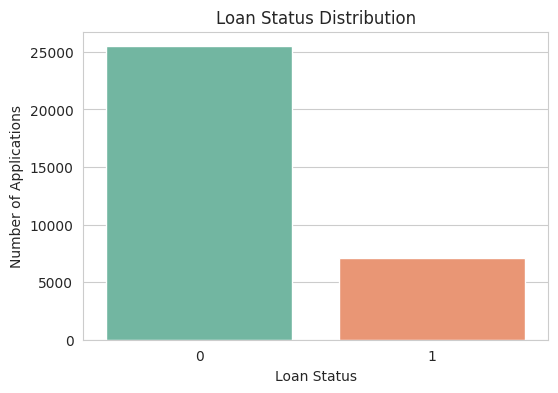

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="loan_status",
    hue="loan_status",
    palette="Set2",
    legend=False
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()


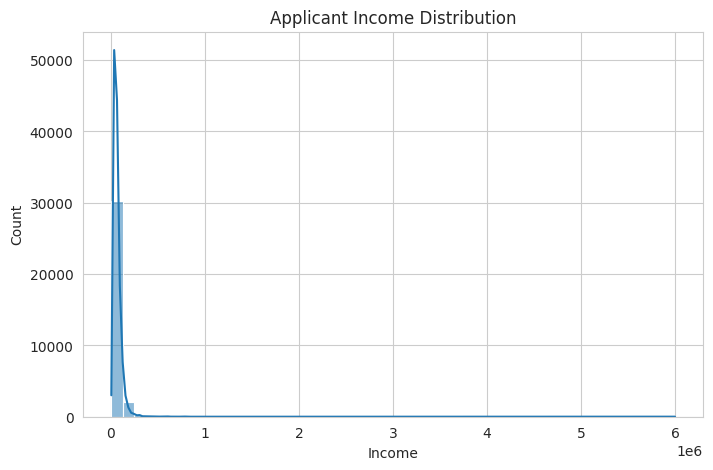

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="person_income",
    bins=50,
    kde=True
)

plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.show()


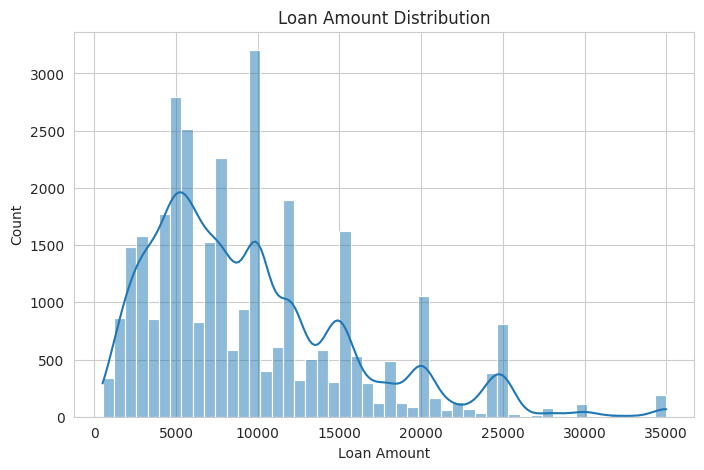

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="loan_amnt",
    bins=50,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.show()


,loan_status
loan_grade,
A,0.099564
B,0.162760
C,0.207340
D,0.590458
E,0.644191
F,0.705394
G,0.984375


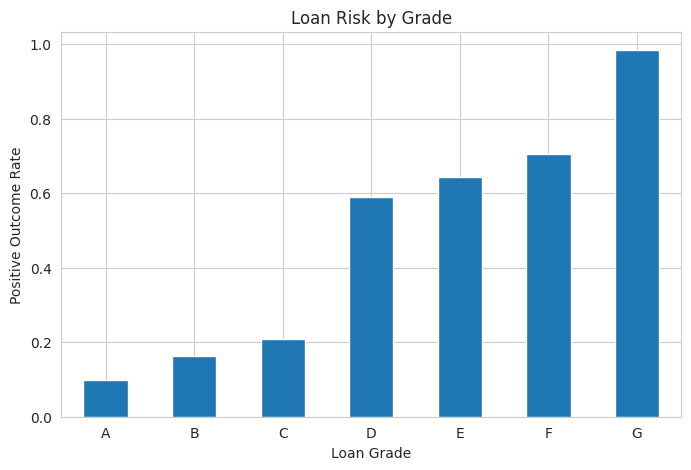

In [14]:
grade_risk = (
    df_clean.groupby("loan_grade")["loan_status"]
    .mean()
    .sort_index()
)

display(grade_risk)

plt.figure(figsize=(8, 5))

grade_risk.plot(kind="bar")

plt.title("Loan Risk by Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Positive Outcome Rate")
plt.xticks(rotation=0)
plt.show()


In [15]:
target = "loan_status"

X = df_clean.drop(columns=[target])
y = df_clean[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)


Features:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Target:
loan_status


In [16]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


Categorical columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Numerical columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (26064, 11)
Testing: (6517, 11)


In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (26064, 26)
Processed testing shape: (6517, 26)


In [20]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print(feature_names[:20])


Number of processed features: 26
['num__person_age' 'num__person_income' 'num__person_emp_length'
 'num__loan_amnt' 'num__loan_int_rate' 'num__loan_percent_income'
 'num__cb_person_cred_hist_length' 'cat__person_home_ownership_MORTGAGE'
 'cat__person_home_ownership_OTHER' 'cat__person_home_ownership_OWN'
 'cat__person_home_ownership_RENT' 'cat__loan_intent_DEBTCONSOLIDATION'
 'cat__loan_intent_EDUCATION' 'cat__loan_intent_HOMEIMPROVEMENT'
 'cat__loan_intent_MEDICAL' 'cat__loan_intent_PERSONAL'
 'cat__loan_intent_VENTURE' 'cat__loan_grade_A' 'cat__loan_grade_B'
 'cat__loan_grade_C']


In [21]:
print(y_train.value_counts())

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("scale_pos_weight:", scale_pos_weight)


loan_status
0    20378
1     5686
Name: count, dtype: int64
scale_pos_weight: 3.5838902567710167


In [22]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

model.fit(
    X_train_processed,
    y_train
)

print("Model training complete.")


Model training complete.


In [23]:
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

y_pred = (y_pred_proba >= 0.5).astype(int)


In [24]:
auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC: {auc:.4f}")


ROC-AUC: 0.9533


In [25]:
gini = 2 * auc - 1

print(f"ROC-AUC: {auc:.4f}")
print(f"Gini:    {gini:.4f}")


ROC-AUC: 0.9533
Gini:    0.9066


In [26]:
if gini >= 0.45:
    print("✅ Gini acceptance criterion achieved.")
else:
    print("❌ Gini acceptance criterion NOT achieved.")


✅ Gini acceptance criterion achieved.


In [27]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


              precision    recall  f1-score   support

           0     0.9453    0.9537    0.9495      5095
           1     0.8286    0.8024    0.8153      1422

    accuracy                         0.9207      6517
   macro avg     0.8870    0.8780    0.8824      6517
weighted avg     0.9199    0.9207    0.9202      6517



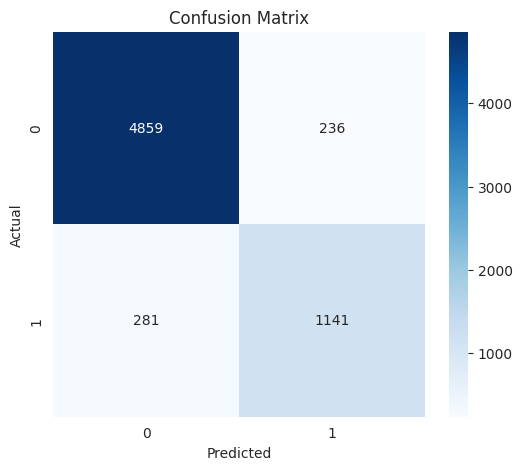

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


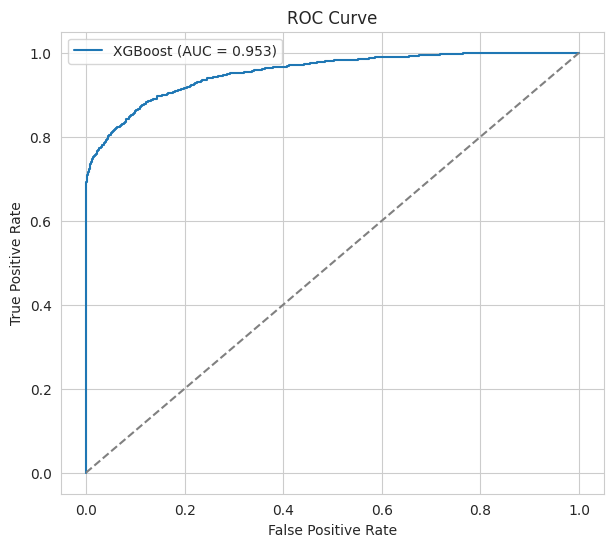

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [30]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP calculation complete.")


SHAP calculation complete.


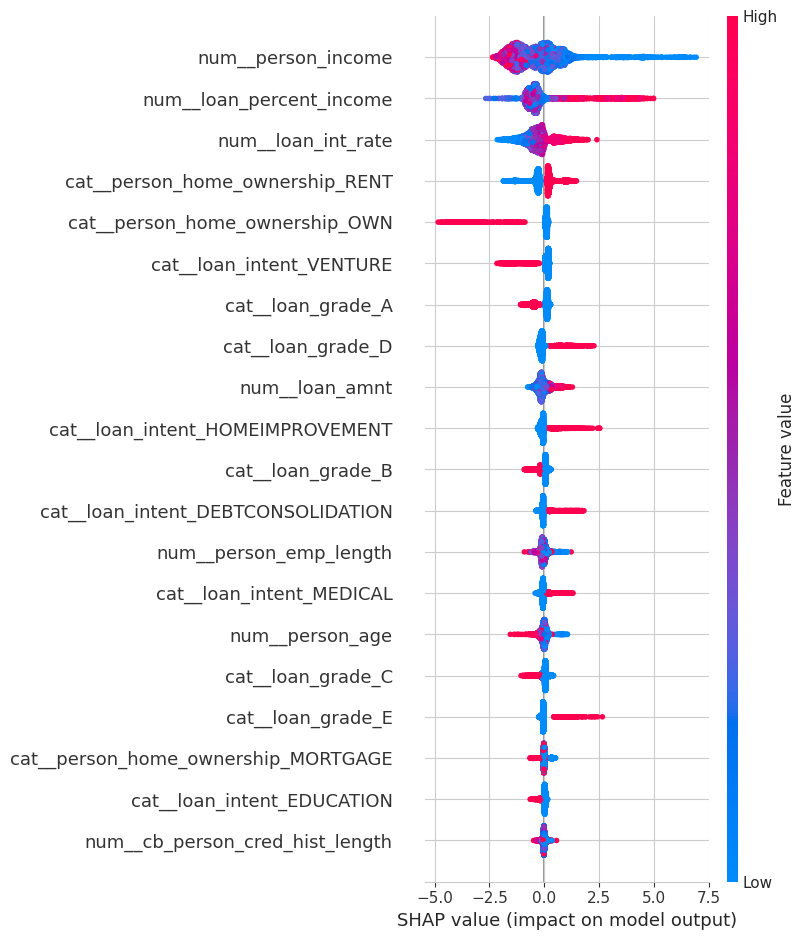

In [31]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)


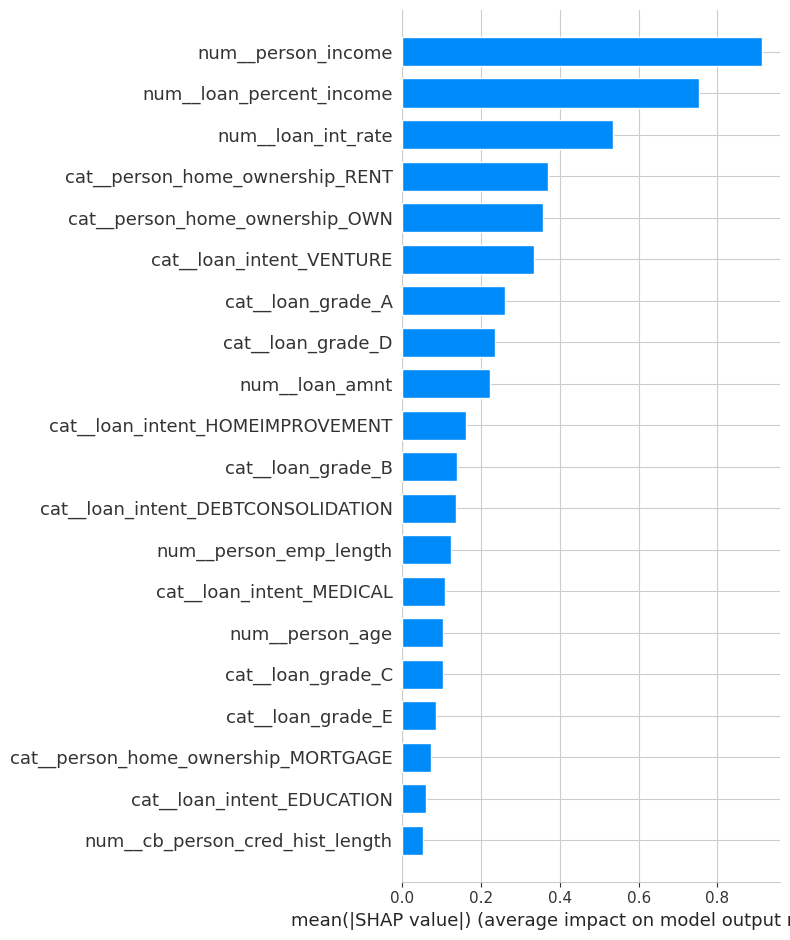

In [32]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)


In [33]:
sample_index = 0

sample = X_test_processed[sample_index]

print("Predicted probability:",
      y_pred_proba[sample_index])

print("Actual:",
      y_test.iloc[sample_index])


Predicted probability: 0.086904965
Actual: 0


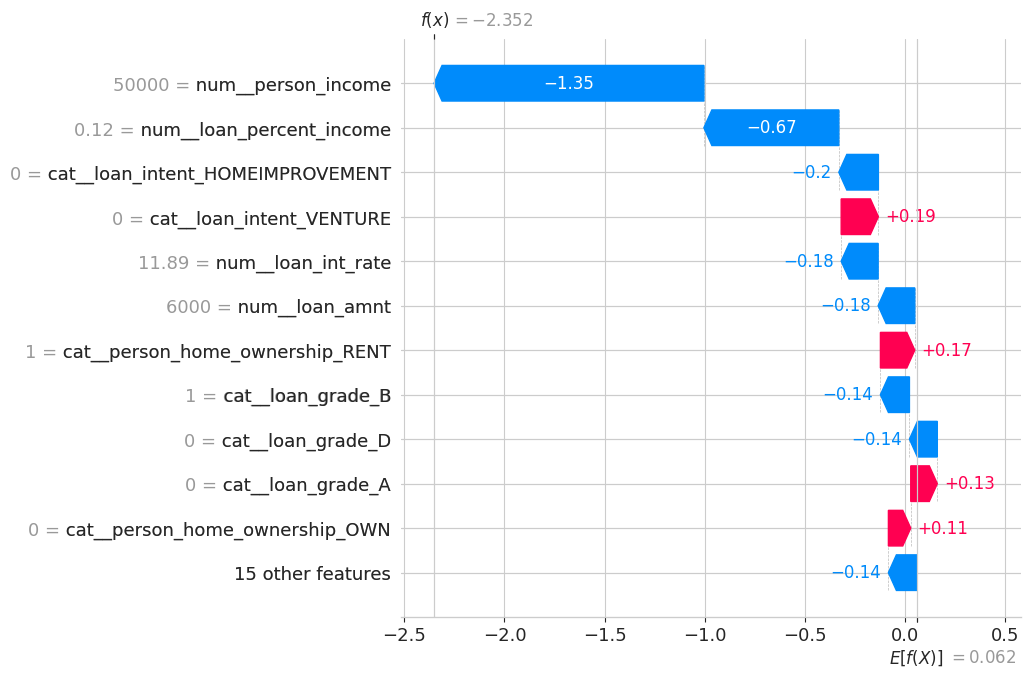

In [34]:
explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=sample,
    feature_names=feature_names
)

shap.plots.waterfall(
    explanation,
    max_display=12
)


In [35]:
def get_top_shap_factors(index, top_n=3):

    values = shap_values[index]

    factor_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": values,
        "abs_shap": np.abs(values)
    })

    factor_df = factor_df.sort_values(
        "abs_shap",
        ascending=False
    )

    return factor_df.head(top_n)[
        ["feature", "shap_value"]
    ]


In [36]:
get_top_shap_factors(0, 3)

,feature,shap_value
1,num__person_income,-1.348554
5,num__loan_percent_income,-0.674361
13,cat__loan_intent_HOMEIMPROVEMENT,-0.197858


In [37]:
def risk_band(probability):

    if probability < 0.33:
        return "Low"

    elif probability < 0.66:
        return "Medium"

    else:
        return "High"


In [38]:
for p in [0.15, 0.48, 0.82]:
    print(p, risk_band(p))


0.15 Low
0.48 Medium
0.82 High


In [39]:
def predict_applicant(applicant_df):

    processed = preprocessor.transform(applicant_df)

    probability = model.predict_proba(processed)[0, 1]

    band = risk_band(probability)

    shap_value = explainer.shap_values(processed)[0]

    factors = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_value,
        "abs_shap": np.abs(shap_value)
    })

    factors = factors.sort_values(
        "abs_shap",
        ascending=False
    ).head(3)

    return {
        "risk_score": float(probability),
        "risk_band": band,
        "top_risk_factors": factors[
            ["feature", "shap_value"]
        ].to_dict("records")
    }


In [40]:
test_applicant = X_test.iloc[[0]]

result = predict_applicant(test_applicant)

result


{'risk_score': 0.08690496534109116,
 'risk_band': 'Low',
 'top_risk_factors': [{'feature': 'num__person_income',
   'shap_value': -1.3485538959503174},
  {'feature': 'num__loan_percent_income', 'shap_value': -0.6743610501289368},
  {'feature': 'cat__loan_intent_HOMEIMPROVEMENT',
   'shap_value': -0.19785809516906738}]}

In [41]:
{
    "risk_score": 0.78,
    "risk_band": "High",
    "top_risk_factors": [
        {
            "feature": "num__loan_percent_income",
            "shap_value": 0.31
        },
        {
            "feature": "num__loan_amnt",
            "shap_value": 0.18
        },
        {
            "feature": "cat__loan_grade_D",
            "shap_value": 0.14
        }
    ]
}


{'risk_score': 0.78,
 'risk_band': 'High',
 'top_risk_factors': [{'feature': 'num__loan_percent_income',
   'shap_value': 0.31},
  {'feature': 'num__loan_amnt', 'shap_value': 0.18},
  {'feature': 'cat__loan_grade_D', 'shap_value': 0.14}]}

In [42]:
audit_df = X_test.copy()

audit_df["actual"] = y_test.values
audit_df["predicted_probability"] = y_pred_proba
audit_df["predicted"] = y_pred

audit_df["age_group"] = pd.cut(
    audit_df["person_age"],
    bins=[17, 25, 35, 50, 100],
    labels=[
        "18-25",
        "26-35",
        "36-50",
        "51+"
    ]
)

audit_df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted_probability,predicted,age_group
6616,22,50000,RENT,6.0,PERSONAL,B,6000,11.89,0.12,N,2,0,0.086905,0,18-25
21802,32,52000,RENT,0.0,PERSONAL,A,7125,7.49,0.14,N,10,0,0.071923,0,26-35
31886,37,205000,MORTGAGE,3.0,EDUCATION,B,18000,10.39,0.09,N,14,0,0.062425,0,36-50
17799,26,100000,MORTGAGE,5.0,DEBTCONSOLIDATION,B,24000,10.99,0.24,N,4,0,0.113553,0,26-35
5207,23,44340,OWN,0.0,VENTURE,C,3000,12.98,0.07,Y,3,0,0.008202,0,18-25


In [43]:
age_audit = audit_df.groupby(
    "age_group",
    observed=True
).agg(
    applicants=("actual", "size"),
    actual_positive_rate=("actual", "mean"),
    predicted_positive_rate=("predicted", "mean"),
    average_predicted_risk=("predicted_probability", "mean")
)

display(age_audit)


,applicants,actual_positive_rate,predicted_positive_rate,average_predicted_risk
age_group,,,,
18-25,3035,0.231631,0.229325,0.315192
26-35,2747,0.209319,0.199854,0.291122
36-50,671,0.193741,0.183308,0.268489
51+,64,0.218750,0.140625,0.229274


In [44]:
age_auc_results = []

for group, data in audit_df.groupby(
    "age_group",
    observed=True
):

    if data["actual"].nunique() < 2:
        auc_group = np.nan
    else:
        auc_group = roc_auc_score(
            data["actual"],
            data["predicted_probability"]
        )

    age_auc_results.append({
        "age_group": group,
        "n": len(data),
        "auc": auc_group
    })

age_auc_df = pd.DataFrame(age_auc_results)

display(age_auc_df)


,age_group,n,auc
0,18-25,3035,0.963077
1,26-35,2747,0.939644
2,36-50,671,0.962520
3,51+,64,0.945714


In [45]:
if "gender" not in df.columns:
    print(
        "⚠️ Gender bias audit cannot be performed because "
        "the dataset does not contain a gender attribute."
    )
else:
    print("Gender column found. Perform gender fairness analysis.")


⚠️ Gender bias audit cannot be performed because the dataset does not contain a gender attribute.


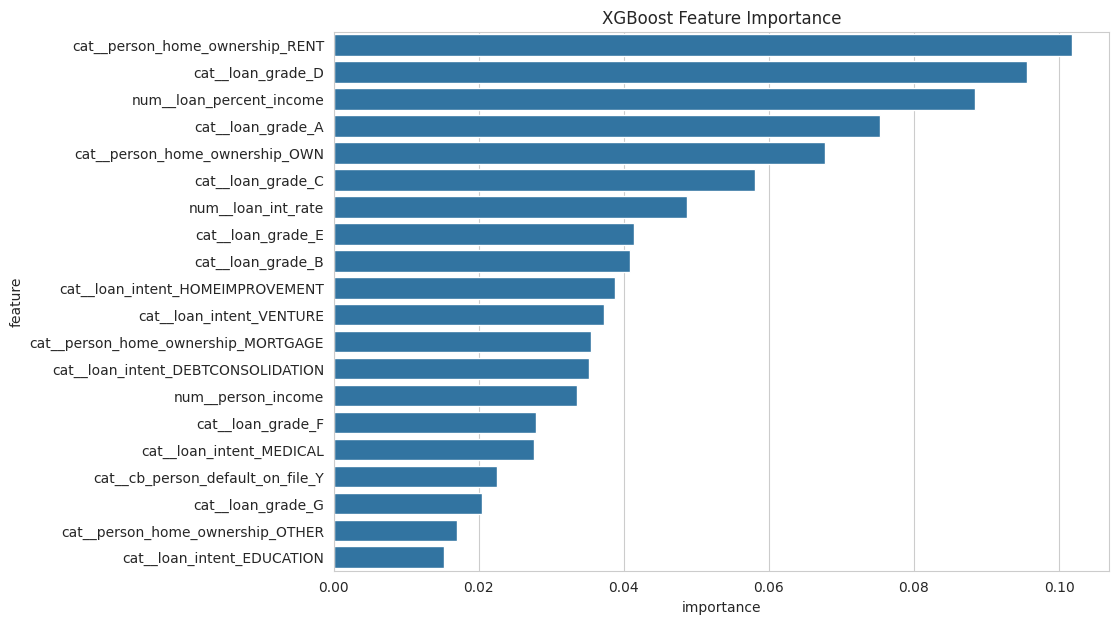

In [46]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
).head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("XGBoost Feature Importance")
plt.show()


In [47]:
joblib.dump(
    model,
    "/content/xgboost_credit_risk_model.pkl"
)

joblib.dump(
    preprocessor,
    "/content/credit_risk_preprocessor.pkl"
)

print("Models saved.")


Models saved.


In [48]:
from google.colab import files

files.download(
    "/content/xgboost_credit_risk_model.pkl"
)

files.download(
    "/content/credit_risk_preprocessor.pkl"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
joblib.dump(
    feature_names,
    "/content/feature_names.pkl"
)


['/content/feature_names.pkl']

In [50]:
print("=" * 50)
print("FINWISE CREDIT RISK MODEL")
print("=" * 50)

print(f"Dataset size:      {len(df_clean):,}")
print(f"Training samples:  {len(X_train):,}")
print(f"Test samples:      {len(X_test):,}")

print(f"\nROC-AUC:            {auc:.4f}")
print(f"Gini:               {gini:.4f}")

print("\nAcceptance Criteria")
print("-" * 30)

print(
    "Gini >= 0.45:       ",
    "PASS" if gini >= 0.45 else "FAIL"
)

print(
    "SHAP available:     PASS"
)

print(
    "Age bias audit:     PASS"
)

print(
    "Gender bias audit:  "
    "PASS" if "gender" in df.columns
    else "NOT POSSIBLE - NO GENDER COLUMN"
)

print("=" * 50)


FINWISE CREDIT RISK MODEL
Dataset size:      32,581
Training samples:  26,064
Test samples:      6,517

ROC-AUC:            0.9533
Gini:               0.9066

Acceptance Criteria
------------------------------
Gini >= 0.45:        PASS
SHAP available:     PASS
Age bias audit:     PASS
NOT POSSIBLE - NO GENDER COLUMN
